# Read In, Clean, and Merge Data

## Read in the data

### Read in the gated station entry data

In [1]:
# ALC
# Imports

import pandas as pd 
from os import walk
import re
import seaborn as sns
import matplotlib.pyplot as plt
import datetime
import math

In [2]:
# ALC
# Gated Station Entries
# From the MBTA Open Data Portal
# https://mbta-massdot.opendata.arcgis.com/datasets/001c177f07594e7c99f193dde32284c9_0/explore
input_file_2022 = "../data/gated station entries/GSE_2022.csv"
input_file_2023 = "../data/gated station entries/GSE_2023.csv"
input_file_2024 = "../data/gated station entries/GSE_2024.csv"
input_file_2025 = "../data/gated station entries/GSE_2025.csv"

gse_2022 = pd.read_csv(input_file_2022)
gse_2023 = pd.read_csv(input_file_2023)
gse_2024 = pd.read_csv(input_file_2024)
gse_2025 = pd.read_csv(input_file_2025)

station_entries = pd.concat([gse_2022, gse_2023, gse_2024, gse_2025])

print(station_entries.shape)

(3731053, 7)


### Read in the service alerts data

In [3]:
# ALC
# these are as downloaded from the MBTA's Open Data Portal. There is one file
# for every month of the year. 
# https://mbta-massdot.opendata.arcgis.com/datasets/90ed9092bd7a4285b296d5ff938edf29_0/explore
# https://mbta-massdot.opendata.arcgis.com/datasets/f960d5089e164fb8b6c6936c70719d72/about
# https://mbta-massdot.opendata.arcgis.com/datasets/ef115f7cf6684360b040b6d1d033eff0/about
# initialize array
alerts = []
alerts_data = []

# we can get a list of all the filepaths we need to read in
for year in [2022, 2023, 2024]:
    for (root, dirs, filenames) in walk(f"../data/service alerts/{year}"):
        for filename in filenames:
            alerts.append(f"{root}/{filename}")
    
# this will give us back a list of dataframes
# as a result of reading in these files
for file in alerts:
    # if there is something like a .DS_STORE, we don't 
    # want to try to read that in. we know we have CSVs
    if (re.search("\.csv$", file)):
        ad = pd.read_csv(file, quotechar='"', low_memory = False)
        alerts_data.append(ad)
    
# we combine our list of dataframes
service_alerts = pd.concat(alerts_data)

# how many rows and columns do we have?
service_alerts.shape

(2095409, 27)

### Read in the speed restrictions data

In [4]:
#ALC
# Speed Restriction Data from MBTA Open Data Portal
# https://mbta-massdot.opendata.arcgis.com/datasets/d73ed67e4cc84a84b818ea2c5caef696/about
slow_zone_files = []
# found this after doing service alerts above
# will focus more on switching to use the api than making consistent for now
for (root, dirs, filenames) in walk("../data/slow zones/"):
    slow_zone_files.extend(filenames)
    break
    
slow_zone_data = []

for file in slow_zone_files:
    path = f"../data/slow zones/{file}"
    if (re.search("\.csv$", file)):
        sz = pd.read_csv(path, quotechar='"')
        slow_zone_data.append(sz)
        
slow_zones = pd.concat(slow_zone_data)
slow_zones.shape

(127922, 32)

### Read in the reliability data

In [5]:
# ALC
# MBTA Reliability data from the MBTA Open Data Portal
# https://mbta-massdot.opendata.arcgis.com/datasets/b3a24561c2104422a78b593e92b566d5_0/explore
reliability_input = "../data/reliability/MBTA Bus, Commuter Rail, & Rapid Transit Reliability.csv"
reliability = pd.read_csv(reliability_input)

reliability.shape

(963838, 13)

## Clean the data and prepare for join

### Make date format consistent

In [6]:
#ALC
def get_date(date):
    return pd.to_datetime(date, format='mixed').dt.date

# the date in the reliability data appears yyyy/mm/dd hh:mm:ss+00
# we will use yyyy-mm-dd for service date
reliability['service_date'] = get_date(reliability['service_date'])

# slow zones uses what we expect but we just rename the column for consistency
slow_zones['Calendar_Date'] = get_date(slow_zones['Calendar_Date'])
slow_zones = slow_zones.rename(columns = {'Calendar_Date': 'service_date'})

# service_alerts is more complicated. there appear to be some problem
# rows. for example in the june 2025 dataset there is a detour alert from july
# of 2024 that never closed
service_alerts['active_period_start_date'] = get_date(service_alerts['active_period_start_date'])
service_alerts['active_period_start_dt'] = get_date(service_alerts['active_period_start_dt'])
service_alerts['active_period_end_dt'] = get_date(service_alerts['active_period_end_dt'])
service_alerts['created_dt'] = get_date(service_alerts['created_dt'])
service_alerts['closed_dt'] = get_date(service_alerts['closed_dt'])
station_entries['service_date'] = get_date(station_entries['service_date'])

### Make line consistent

In [7]:
# ALC
def simplify_route(line):
    if pd.isna(line) or 'Silver Line' in line:
        return None
    elif 'Green Line' in line or 'Green-' in line:
        return 'green'
    elif 'Red Line' in line or 'Red' in line:
        return "red"
    elif 'Blue Line' in line or 'Blue' in line:
        return 'blue'
    elif 'Orange Line' in line or 'Orange' in line:
        return 'orange'
    else:
        return line

# station entry lines
station_entries['route_or_line'] = station_entries['route_or_line'].apply(simplify_route)

# there is silver line data in here which is out of scope
station_entries = station_entries[station_entries['route_or_line'].isin(['green', 'red', 'blue', 'orange'])]
station_entries = station_entries.rename(columns = {'gated_entries': 'est_ridership',
                                                   'route_or_line': 'line'})

# slow zones lines
slow_zones['line'] = slow_zones['Line'].apply(simplify_route)

# reliability lines, cr and rt
reliability['line'] = reliability['gtfs_route_long_name'].apply(simplify_route)

# this removes out of scope bus data
reliability = reliability[reliability['line'].notna()]

service_alerts['route_id'] = service_alerts['route_id'].apply(simplify_route)
service_alerts = service_alerts.rename(columns = {'route_id': 'line'})

### Aggregation

In [8]:
# ALC
# function to aggregate reliability data by date and line
# get one row per line per date with an aggregate score
def agg_reliability_data_daily(reliability):
    return reliability.groupby(['service_date', 'line'], as_index=False)[
        ['otp_numerator', 'otp_denominator']
    ].sum()
    
# gated station entries are given by the half hour. we will need to
# aggregate these down to the day
def agg_station_entries_daily(station_entries):
    return station_entries.groupby(['service_date', 'line'], as_index=False)[
               'est_ridership'
           ].sum()

# count and distane of slow zones daily
def agg_slow_zones_daily(slow_zones):
    return slow_zones.groupby(['service_date', 'line'], as_index=False).agg(
        num_slow_zones = ('ID', 'nunique'),
        total_track_pct = ('Line_Restricted_Track_Pct', 'sum'),
        total_miles_affected = ('Restriction_Distance_Miles', 'sum')
    )

## Relate the data

In [9]:
# ALC
# join datasets
# does it have to be done two at a time?
station_entries_reliability = pd.merge(
    agg_station_entries_daily(station_entries), 
    agg_reliability_data_daily(reliability), 
    on = ['service_date', 'line'], 
    how = 'inner')
    
# doing a left join here. if there is no data in the 
# slow zones file, it means slow zones = none
merged_data = pd.merge(
    station_entries_reliability,
    agg_slow_zones_daily(slow_zones),
    on = ['service_date', 'line'],
    how = 'left'
)

merged_data = merged_data[merged_data['service_date'] > datetime.date(2022, 12, 31)]

In [10]:
# JJ
# Expand service alerts and prep columns

service_alerts['active_period_start_dt'] = get_date(service_alerts['active_period_start_dt'])
service_alerts['active_period_end_dt'] = get_date(service_alerts['active_period_end_dt'])

service_alerts['line'] = service_alerts['line'].astype(str).apply(simplify_route)
service_alerts = service_alerts[service_alerts['line'].isin(['red', 'blue', 'green', 'orange'])]

In [11]:
# JJ
# Deduplicate alerts by alert_id first
# ALC added next line because some alerts have dates but
# the deduplication was only keeping one entry without them
service_alerts = service_alerts[
    (~service_alerts['active_period_start_dt'].isna()) &
    (~service_alerts['active_period_end_dt'].isna())]
service_alerts = service_alerts.drop_duplicates(subset=["alert_id"])

In [12]:
# JJ
# Expand alerts by date
expanded_alerts = []
for _, row in service_alerts.iterrows():
    if pd.isna(row['active_period_start_dt']) or pd.isna(row['active_period_end_dt']):
        continue
    for d in pd.date_range(row['active_period_start_dt'], row['active_period_end_dt']):
        expanded_alerts.append({
            'service_date': d.date(),
            'line': row['line'],
            # ALC added
            'alert_cause': row['cause_detail'],
            'alert_effect': row['effect_detail'],
            'alert_id': row['alert_id'],
            'count': 1
        })

expanded_alerts_df = pd.DataFrame(expanded_alerts)

In [13]:
# JJ
# Aggregate counts

daily_alert_counts = (
    expanded_alerts_df
    .groupby(['service_date', 'line'], as_index=False)
    .size()
    .rename(columns={'size': 'num_alerts'})
)

In [14]:
# ALC
# grab some key alert types
alert_summary = (
    expanded_alerts_df
    .groupby(['service_date', 'line'])
    .agg(
        has_special_event = ('alert_cause', lambda x: 'SPECIAL_EVENT' in x.values),
        alert_effect_delay = ('alert_effect', lambda x: (x == 'DELAY').sum()),
        alert_effect_shuttle = ('alert_effect', lambda x: (x == 'SHUTTLE').sum())
    )
    .reset_index()
)

In [15]:
# ALC
merged_data['otp_score'] = merged_data['otp_numerator'] / merged_data['otp_denominator']
merged_data['num_slow_zones']
merged_data.drop('otp_numerator', axis=1, inplace=True)
merged_data.drop('otp_denominator', axis=1, inplace=True)

# if data is not present it means there were no slow zones
merged_data['num_slow_zones'] = merged_data['num_slow_zones'].fillna(0)
merged_data['total_track_pct'] = merged_data['total_track_pct'].fillna(0)
merged_data['total_miles_affected'] = merged_data['total_miles_affected'].fillna(0)
# these may be useful
merged_data['day_of_week'] = pd.to_datetime(merged_data['service_date']).dt.day_name()
merged_data['month'] = pd.to_datetime(merged_data['service_date']).dt.month_name()
# ideas to add: mark federal holidays, special event days, periods of known
# entire line closures, etc

merged_data.head()

,service_date,line,est_ridership,num_slow_zones,total_track_pct,total_miles_affected,otp_score,day_of_week,month
1430,2023-01-01,blue,15214.400000,0.0,0.000000,0.000000,0.993762,Sunday,January
1431,2023-01-01,green,22745.689929,17.0,0.032971,1.780114,0.795319,Sunday,January
1432,2023-01-01,orange,24492.170000,12.0,0.088899,2.003788,0.978458,Sunday,January
1433,2023-01-01,red,27863.440000,23.0,0.074641,3.538731,0.900584,Sunday,January
1434,2023-01-02,blue,19025.400000,0.0,0.000000,0.000000,0.986604,Monday,January


In [16]:
# JJ
# Merge with merged data

final_data_v2 = pd.merge(
    merged_data,
    daily_alert_counts,
    on=["service_date", "line"],
    how="left"
)

# ALC
final_data_v2 = pd.merge(
    final_data_v2,
    alert_summary,
    on=["service_date", "line"],
    how="left"
)
final_data_v2.head(5)

,service_date,line,est_ridership,num_slow_zones,total_track_pct,total_miles_affected,otp_score,day_of_week,month,num_alerts,has_special_event,alert_effect_delay,alert_effect_shuttle
0,2023-01-01,blue,15214.400000,0.0,0.000000,0.000000,0.993762,Sunday,January,NaN,NaN,NaN,NaN
1,2023-01-01,green,22745.689929,17.0,0.032971,1.780114,0.795319,Sunday,January,NaN,NaN,NaN,NaN
2,2023-01-01,orange,24492.170000,12.0,0.088899,2.003788,0.978458,Sunday,January,2.0,False,1.0,1.0
3,2023-01-01,red,27863.440000,23.0,0.074641,3.538731,0.900584,Sunday,January,NaN,NaN,NaN,NaN
4,2023-01-02,blue,19025.400000,0.0,0.000000,0.000000,0.986604,Monday,January,NaN,NaN,NaN,NaN


In [17]:
# ALC
# lack of service alerts, fill with 0
final_data_v2['num_alerts'] = final_data_v2['num_alerts'].fillna(0)
final_data_v2['has_special_event'] = final_data_v2['has_special_event'].fillna(False)
final_data_v2['alert_effect_delay'] = final_data_v2['alert_effect_delay'].fillna(0)
final_data_v2['alert_effect_shuttle'] = final_data_v2['alert_effect_shuttle'].fillna(0)

/var/folders/47/l58zqr11681971v3fpf5rx880000gn/T/ipykernel_13589/3061829417.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  final_data_v2['has_special_event'] = final_data_v2['has_special_event'].fillna(False)


In [18]:
# ALC
final_data_v2.corr(numeric_only = True)

,est_ridership,num_slow_zones,total_track_pct,total_miles_affected,otp_score,num_alerts,has_special_event,alert_effect_delay,alert_effect_shuttle
est_ridership,1.000000,0.421414,-0.097568,0.274147,0.113591,0.024265,0.019056,0.205069,-0.064720
num_slow_zones,0.421414,1.000000,0.137445,0.923036,-0.245081,0.362909,-0.012119,0.350590,0.241243
total_track_pct,-0.097568,0.137445,1.000000,0.397312,0.159315,-0.104056,-0.043406,-0.105543,-0.017509
total_miles_affected,0.274147,0.923036,0.397312,1.000000,-0.299245,0.345183,-0.026106,0.314681,0.207860
otp_score,0.113591,-0.245081,0.159315,-0.299245,1.000000,-0.333889,-0.045425,-0.333722,-0.115834
num_alerts,0.024265,0.362909,-0.104056,0.345183,-0.333889,1.000000,0.048249,0.720656,0.587326
has_special_event,0.019056,-0.012119,-0.043406,-0.026106,-0.045425,0.048249,1.000000,0.043348,-0.009786
alert_effect_delay,0.205069,0.350590,-0.105543,0.314681,-0.333722,0.720656,0.043348,1.000000,0.173448
alert_effect_shuttle,-0.064720,0.241243,-0.017509,0.207860,-0.115834,0.587326,-0.009786,0.173448,1.000000


In [19]:
# get some summary statistics for our numeric columns
pd.set_option('display.max_columns', None)

for x in ['est_ridership', 'num_slow_zones', 'total_track_pct',
          'total_miles_affected', 'otp_score', 'num_alerts']:
        print(x)
        print(final_data_v2[x].describe())
        print("skew: " + str(final_data_v2[x].skew()))
        print("kurtosis: " + str(final_data_v2[x].kurt()))

est_ridership
count      2056.000000
mean      53453.791443
std       23868.360808
min        2488.590000
25%       35146.850000
50%       47540.791585
75%       76209.985000
max      129547.140000
Name: est_ridership, dtype: float64
skew: 0.3552517302896341
kurtosis: -0.9381528261964682
num_slow_zones
count    2056.000000
mean       41.697471
std        29.552854
min         0.000000
25%        16.000000
50%        35.000000
75%        63.000000
max       116.000000
Name: num_slow_zones, dtype: float64
skew: 0.7817808488290754
kurtosis: -0.3485059700015438
total_track_pct
count    2056.000000
mean        0.210322
std         0.122029
min         0.000000
25%         0.166264
50%         0.198393
75%         0.264520
max         0.890523
Name: total_track_pct, dtype: float64
skew: 0.9686451936900974
kurtosis: 3.7272577814975922
total_miles_affected
count    2056.000000
mean        6.332326
std         3.988564
min         0.000000
25%         3.948011
50%         4.580398
75%         9

In [20]:
# ALC
def summarize_categorical(data, column):
    # count of appearances
    counts = data[column].value_counts()
    # proportion but multiply by 100 for percent
    proportions = data[column].value_counts(normalize = True) * 100
    # print it cleanly
    summary = pd.concat([counts.rename("Count"),
                         proportions.rename("Proportion (%)")], axis = 1)
    print(f"\n" + column + "\n")
    print(summary)
    return summary

# these are our categorical variables for now
for cat_var in ['line', 'day_of_week', 'month']:
    summarize_categorical(final_data_v2, cat_var)


line

        Count  Proportion (%)
line                         
blue      514            25.0
green     514            25.0
orange    514            25.0
red       514            25.0

day_of_week

             Count  Proportion (%)
day_of_week                       
Sunday         296       14.396887
Monday         296       14.396887
Tuesday        296       14.396887
Wednesday      292       14.202335
Thursday       292       14.202335
Friday         292       14.202335
Saturday       292       14.202335

month

           Count  Proportion (%)
month                           
January      248       12.062257
March        248       12.062257
April        240       11.673152
May          236       11.478599
February     228       11.089494
July         124        6.031128
August       124        6.031128
October      124        6.031128
December     124        6.031128
June         120        5.836576
September    120        5.836576
November     120        5.836576


In [21]:
# JJ
# save to CSV
final_data_v2.to_csv("../data/final_merged_data_v2.csv", index=False)

In [22]:
# JJ
# Check service alert count per line
service_alerts['line'].value_counts(dropna=False)

line
green     1629
red       1468
orange     815
blue       616
Name: count, dtype: int64

In [23]:
# ALC official MBTA hex codes
blue_line_color = '#003DA5'
green_line_color = '#00843D'
red_line_color = '#DA291C'
orange_line_color = '#ED8B00'

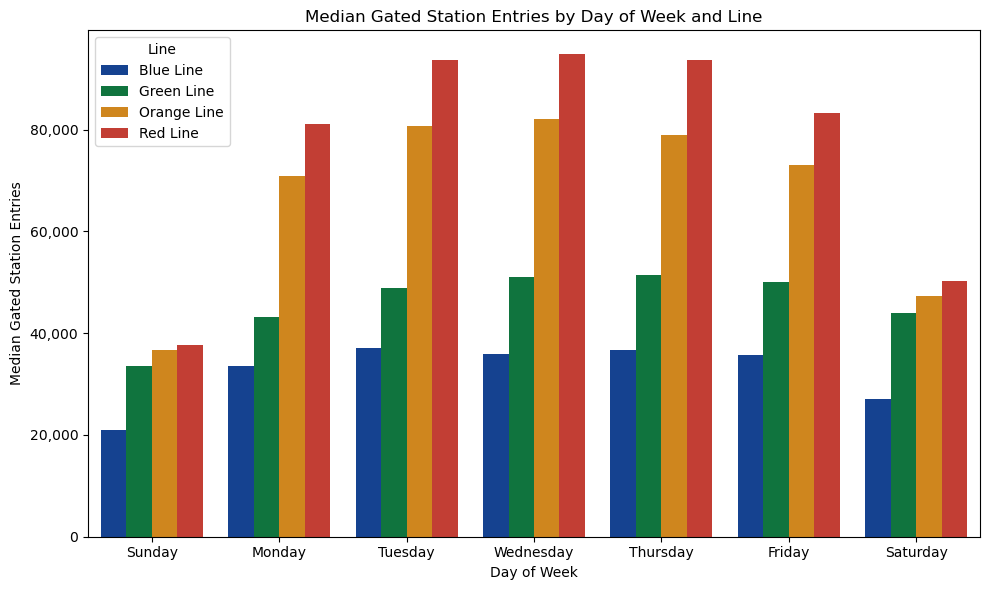

In [27]:
# ALC
# 1st plot, show how day of the week may be something we need
# to handle
plt.figure(figsize = (10, 6))

# have colors match line
palette = {'green': green_line_color, 'blue': blue_line_color, 
           'orange': orange_line_color, 'red': red_line_color}

sns.barplot(
    data = merged_data,
    x = 'day_of_week',
    y = 'est_ridership',
    hue = 'line',
    estimator = 'median',
    errorbar = None,
    palette = palette
)

# labels
plt.title('Median Gated Station Entries by Day of Week and Line')
plt.ylabel('Median Gated Station Entries')
plt.gca().yaxis.set_major_formatter(lambda x, pos: f'{x:,.0f}')
plt.xlabel('Day of Week')
# make better labels
plt.legend(title = 'Line', 
           labels = ['Blue Line', 'Green Line', 'Orange Line', 'Red Line'])
plt.tight_layout()
plt.palette = palette
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


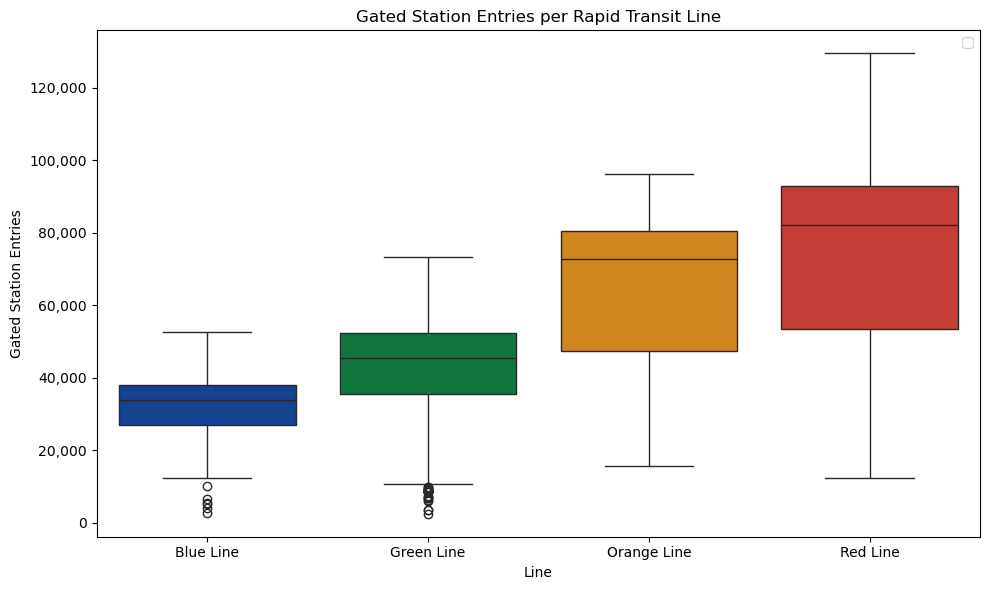

In [25]:
# ALC
# we'll need to look at train lines individually
plt.figure(figsize = (10, 6))

sns.boxplot(x = 'line', 
            y = 'est_ridership',
            hue = 'line',
            palette = palette,
            data = merged_data)

lines = ['Blue Line', 'Green Line', 'Orange Line', 'Red Line']
# labels
plt.title('Gated Station Entries per Rapid Transit Line')
plt.xlabel('Line')
plt.ylabel('Gated Station Entries')
plt.gca().yaxis.set_major_formatter(lambda x, pos: f'{x:,.0f}')
plt.xticks(ticks = [0, 1, 2, 3], labels = lines)
# make better labels
plt.legend()
plt.tight_layout()
plt.palette = palette
plt.show()

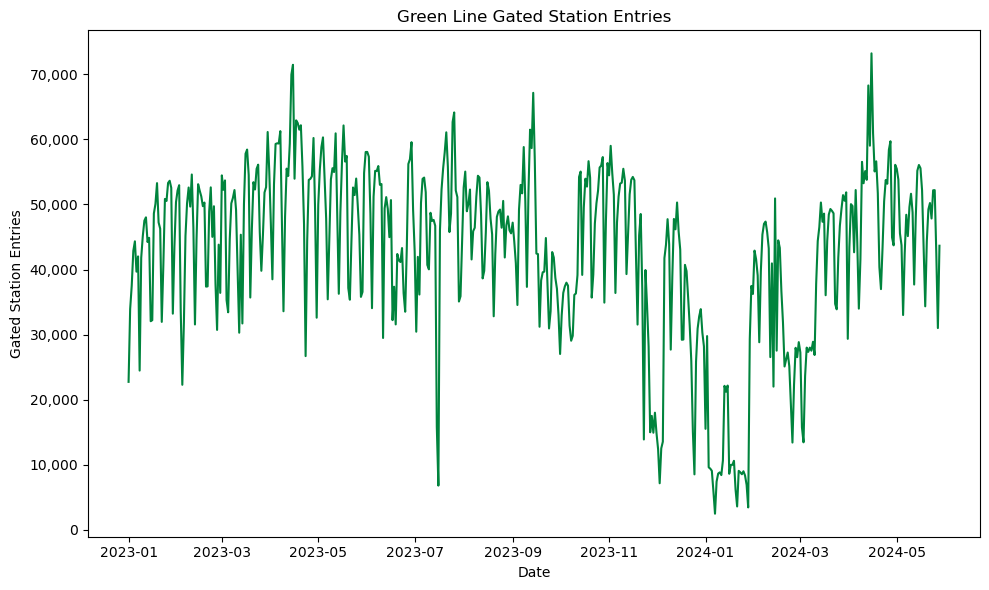

In [26]:
# ALC
plt.figure(figsize = (10, 6))

sns.lineplot(x = 'service_date', 
            y = 'est_ridership',
             color = green_line_color,
            data = merged_data[merged_data['line'] == 'green'])
# labels
plt.title('Green Line Gated Station Entries')
plt.xlabel('Date')
plt.ylabel('Gated Station Entries')
plt.gca().yaxis.set_major_formatter(lambda x, pos: f'{x:,.0f}')
plt.tight_layout()
plt.show()

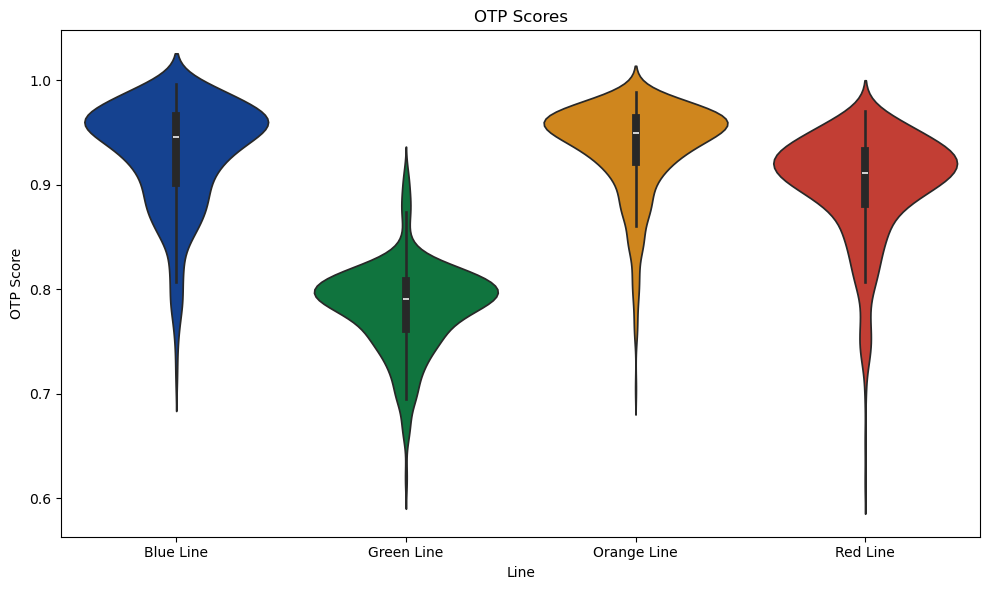

In [32]:
# ALC
# violin plot showing OTP scores
plt.figure(figsize = (10, 6))

sns.violinplot(x = 'line', 
            y = 'otp_score',
            palette = palette,
               hue = 'line',
            data = merged_data)
# labels
plt.title('OTP Scores')
plt.xlabel('Line')
plt.ylabel('OTP Score')
plt.tight_layout()
plt.xticks(ticks = [0, 1, 2, 3], labels = lines)
plt.show()

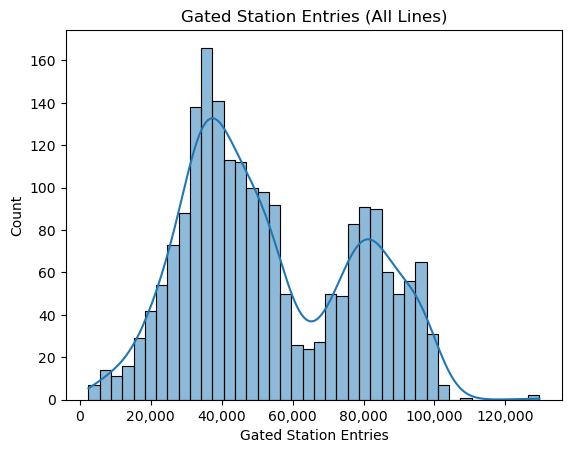

In [39]:
# ALC
sns.histplot(merged_data["est_ridership"], bins=40, kde=True)
plt.xlabel('Gated Station Entries')
plt.gca().xaxis.set_major_formatter(lambda x, pos: f'{x:,.0f}')
plt.title('Gated Station Entries (All Lines)')
plt.show()